## 1. Problem Framing

# Causal pipeline 3 (new): Social media posts → engagement and donation value

Uses only `lighthouse_csv_v7/social_media_posts.csv`.

- **Model A target**: `engagement_rate` (excludes `likes`, `comments`, `shares`, `reach` because engagement is computed from them)
- **Model B target**: `estimated_donation_value_php` (excludes `donation_referrals` to reduce leakage)

Both follow the Chapter 10-style MLR diagnostics flow: initial OLS → normality checks + label transforms → VIF (>7) iterative removal → interaction (`has_call_to_action × features_resident_story`) → refined model → top-5 t-score plots.

**Approach type (textbook framing):** This is an **explanatory/causal relationship** analysis (not a prediction pipeline). We use regression + diagnostics to understand *associations* that can inform decisions and future experiments.

## 2. Data Acquisition, Preparation & Exploration

This section loads the relevant tables, explains any joins, and explores distributions, missingness, and correlations. The goal is to make the modeling choices reproducible and understandable to non-technical stakeholders.

In [ ]:
# Quick EDA helpers (kept lightweight so notebook runs fast)

def report_missing(df, name='df'):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    print(f"Missingness ({name}):")
    display(miss.to_frame('pct_missing').head(30))


def numeric_overview(df, name='df'):
    num = df.select_dtypes(include=['number'])
    print(f"Numeric overview ({name}):")
    display(num.describe().T)


def corr_heatmap(df, name='df', max_cols=25):
    num = df.select_dtypes(include=['number'])
    if num.shape[1] == 0:
        print('No numeric columns for correlation.')
        return
    cols = list(num.columns[:max_cols])
    c = num[cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(c, aspect='auto')
    plt.xticks(range(len(cols)), cols, rotation=90)
    plt.yticks(range(len(cols)), cols)
    plt.title(f"Correlation heatmap (first {len(cols)} numeric cols) - {name}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


In [22]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats as scipy_stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path


def find_project_root(marker_dir="lighthouse_csv_v7"):
    """Walk upward from CWD until marker_dir is found."""
    p = Path.cwd().resolve()
    for cand in [p] + list(p.parents):
        if (cand / marker_dir).exists():
            return cand
    raise FileNotFoundError(
        f"Could not find {marker_dir}/ by walking up from {Path.cwd().resolve()}"
    )


PROJECT_ROOT = find_project_root("lighthouse_csv_v7")
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"

VIF_THRESHOLD = 7.0


def prepare_features(df, label_col, extra_drop=None):
    extra_drop = extra_drop or []
    d = df.drop(columns=[c for c in extra_drop if c in df.columns], errors="ignore").copy()
    y = pd.to_numeric(d[label_col], errors="coerce")
    d = d.dropna(subset=[label_col])
    y = pd.to_numeric(d[label_col], errors="coerce")
    X = d.drop(columns=[label_col])

    # drop id-like columns
    id_cols = [c for c in X.columns if str(c).lower() == "id" or str(c).lower().endswith("_id")]
    X = X.drop(columns=id_cols, errors="ignore")

    for c in X.select_dtypes(include=[bool]).columns:
        X[c] = X[c].astype(int)

    num_cols = list(X.select_dtypes(include=[np.number]).columns)
    cat_cols = [c for c in X.columns if c not in num_cols]

    for c in num_cols:
        if X[c].isna().any():
            X[c] = X[c].fillna(X[c].median())
    for c in cat_cols:
        if X[c].isna().any():
            m = X[c].mode()
            X[c] = X[c].fillna(m.iloc[0] if len(m) else "Unknown")

    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    X[X.select_dtypes(include=[bool]).columns] = X.select_dtypes(include=[bool]).astype(int)
    X = X.select_dtypes(include=[np.number])

    nz = X.std(numeric_only=True) > 0
    X = X.loc[:, nz[nz].index]
    return X, y


def ols_fit(X, y):
    Xc = sm.add_constant(X, has_constant="add")
    return sm.OLS(y, Xc).fit(), Xc


def vif_series(X_with_const):
    arr = np.asarray(X_with_const, dtype=float)
    return pd.Series([variance_inflation_factor(arr, i) for i in range(arr.shape[1])], index=X_with_const.columns)


def remove_high_vif_one_at_a_time(X, y, threshold=VIF_THRESHOLD, max_iter=300):
    Xw = X.copy()
    removed = []
    for _ in range(max_iter):
        if Xw.shape[1] == 0:
            break
        v = vif_series(sm.add_constant(Xw, has_constant="add")).drop("const", errors="ignore")
        if v.empty or float(v.max()) <= threshold:
            break
        worst = v.idxmax()
        removed.append((worst, float(v.max())))
        Xw = Xw.drop(columns=[worst])
    return Xw, removed


def shapiro_tail(x, max_n=5000):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.nan, np.nan
    if len(x) > max_n:
        rng = np.random.default_rng(42)
        x = rng.choice(x, size=max_n, replace=False)
    return scipy_stats.shapiro(x)


def plot_top_t(model, k=5, title="Top features by |t|"):
    t = model.tvalues.drop("const", errors="ignore").dropna()
    top_idx = t.abs().sort_values(ascending=False).head(k).index
    top = t.loc[top_idx].sort_values()
    plt.figure(figsize=(8, 4))
    colors = ["#1f77b4" if v > 0 else "#d62728" for v in top.values]
    plt.barh(top.index, top.values, color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("t-statistic")
    plt.tight_layout()
    plt.show()


def plot_top_t_positive(model, k=5, title="Top features by t (most positive)"):
    t = model.tvalues.drop("const", errors="ignore").dropna()
    top = t.sort_values(ascending=False).head(k)
    plt.figure(figsize=(8, 4))
    plt.barh(top.index[::-1], top.values[::-1], color="#1f77b4")
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("t-statistic")
    plt.tight_layout()
    plt.show()


posts = pd.read_csv(DATA_DIR / "social_media_posts.csv")

# numeric + boolean typing
num_cols = [
    "post_hour","num_hashtags","mentions_count","caption_length",
    "boost_budget_php","impressions","reach","likes","comments","shares","saves",
    "click_throughs","video_views","profile_visits","donation_referrals",
    "estimated_donation_value_php","follower_count_at_post","watch_time_seconds",
    "avg_view_duration_seconds","subscriber_count_at_post","forwards","engagement_rate"
]
for c in num_cols:
    if c in posts.columns:
        posts[c] = pd.to_numeric(posts[c], errors="coerce")

for b in ["has_call_to_action", "features_resident_story", "is_boosted"]:
    if b in posts.columns:
        posts[b] = posts[b].fillna(False).astype(bool).astype(int)

posts["log_followers"] = np.log1p(posts["follower_count_at_post"].fillna(0))
posts["created_at"] = pd.to_datetime(posts["created_at"], errors="coerce")

posts.shape

(812, 40)

                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     21.35
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          3.08e-121
Time:                        12:40:30   Log-Likelihood:                 1585.6
No. Observations:                 812   AIC:                            -3055.
Df Residuals:                     754   BIC:                            -2783.
Df Model:                          57                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

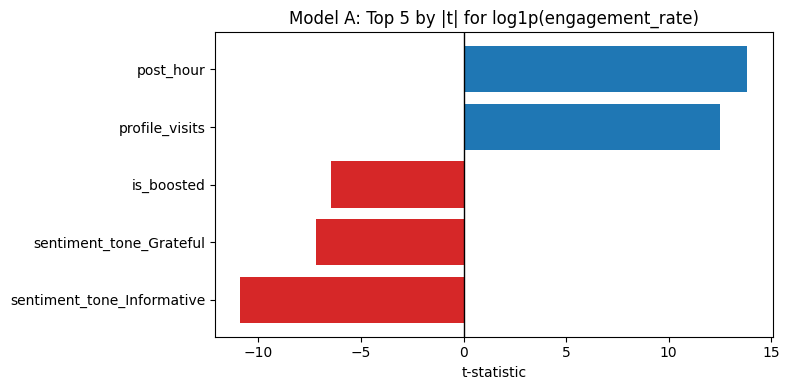

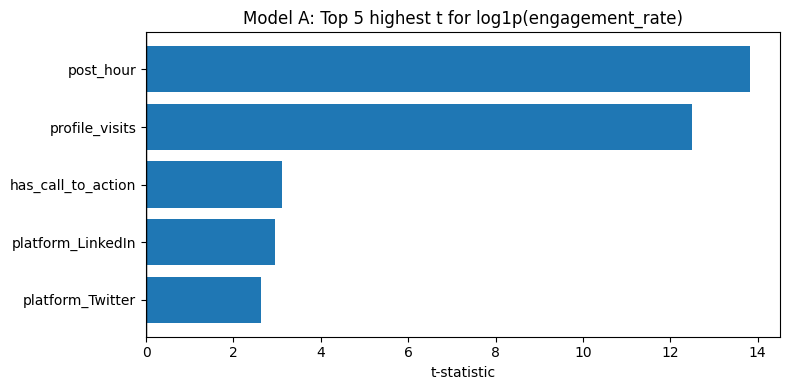

In [23]:
# Model A: engagement_rate
# Exclude mechanical components of engagement_rate

dropA = [
    "post_id","platform_post_id","post_url","caption","hashtags","campaign_name","created_at",
    "likes","comments","shares","reach",
    "impressions",
]

XA, yA = prepare_features(posts, "engagement_rate", extra_drop=dropA)
mA0, _ = ols_fit(XA, yA)
print(mA0.summary())

print("Skew raw:", float(pd.Series(yA).skew()))
print("Shapiro p (subsample):", shapiro_tail(yA)[1])
print("Residual JB p:", sm.stats.stattools.jarque_bera(mA0.resid)[1])

yA_used = yA
labelA = "engagement_rate"
yA_clip = np.clip(yA, 0, None)
yA_log = np.log1p(yA_clip)
if abs(pd.Series(yA_log).skew()) < abs(pd.Series(yA).skew()):
    yA_used = yA_log
    labelA = "log1p(engagement_rate)"

mA1, _ = ols_fit(XA, yA_used)
print("Using label:", labelA)
print(mA1.summary())

XA_v, _ = remove_high_vif_one_at_a_time(XA, yA_used)
XA_int = XA_v.copy()
if "has_call_to_action" in XA_int.columns and "features_resident_story" in XA_int.columns:
    XA_int["cta_x_story"] = XA_int["has_call_to_action"] * XA_int["features_resident_story"]

mA_final, _ = ols_fit(XA_int, yA_used)
print(mA_final.summary())
plot_top_t(mA_final, k=5, title=f"Model A: Top 5 by |t| for {labelA}")
plot_top_t_positive(mA_final, k=5, title=f"Model A: Top 5 highest t for {labelA}")


                                 OLS Regression Results                                 
Dep. Variable:     estimated_donation_value_php   R-squared:                       0.801
Model:                                      OLS   Adj. R-squared:                  0.785
Method:                           Least Squares   F-statistic:                     49.64
Date:                          Tue, 07 Apr 2026   Prob (F-statistic):          3.97e-222
Time:                                  12:40:31   Log-Likelihood:                -10019.
No. Observations:                           812   AIC:                         2.016e+04
Df Residuals:                               750   BIC:                         2.045e+04
Df Model:                                    61                                         
Covariance Type:                      nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------

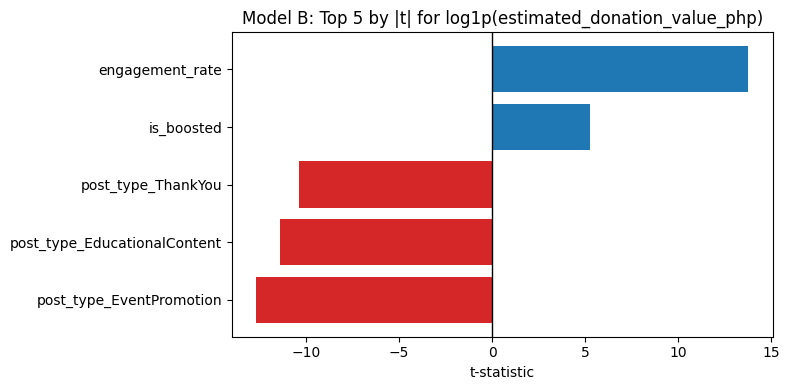

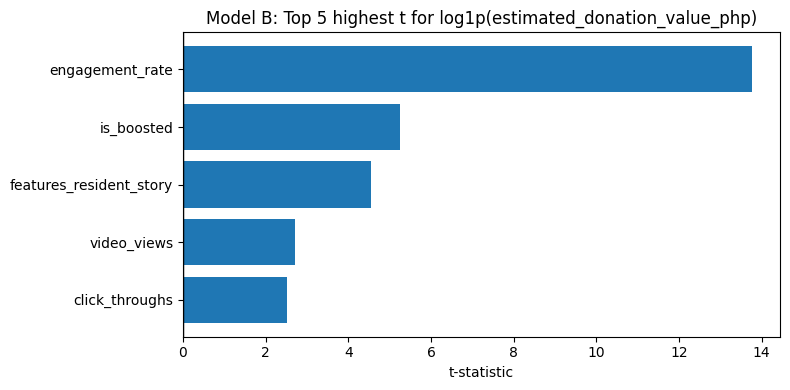

In [24]:
# Model B: estimated_donation_value_php
# Exclude donation_referrals to reduce leakage

dropB = [
    "post_id","platform_post_id","post_url","caption","hashtags","campaign_name","created_at",
    "donation_referrals",
]

XB, yB = prepare_features(posts, "estimated_donation_value_php", extra_drop=dropB)
mB0, _ = ols_fit(XB, yB)
print(mB0.summary())

print("Skew raw:", float(pd.Series(yB).skew()))
print("Shapiro p (subsample):", shapiro_tail(yB)[1])
print("Residual JB p:", sm.stats.stattools.jarque_bera(mB0.resid)[1])

yB_used = yB
labelB = "estimated_donation_value_php"
yB_clip = np.clip(yB, 0, None)
yB_log = np.log1p(yB_clip)
if abs(pd.Series(yB_log).skew()) < abs(pd.Series(yB).skew()):
    yB_used = yB_log
    labelB = "log1p(estimated_donation_value_php)"

mB1, _ = ols_fit(XB, yB_used)
print("Using label:", labelB)
print(mB1.summary())

XB_v, _ = remove_high_vif_one_at_a_time(XB, yB_used)
XB_int = XB_v.copy()
if "has_call_to_action" in XB_int.columns and "features_resident_story" in XB_int.columns:
    XB_int["cta_x_story"] = XB_int["has_call_to_action"] * XB_int["features_resident_story"]

mB_final, _ = ols_fit(XB_int, yB_used)
print(mB_final.summary())
plot_top_t(mB_final, k=5, title=f"Model B: Top 5 by |t| for {labelB}")
plot_top_t_positive(mB_final, k=5, title=f"Model B: Top 5 highest t for {labelB}")


# Causal pipeline 3 (new): Social media posts → engagement and donation value

## Problem framing
**Question A:** Are **CTA** (`has_call_to_action`) and **story-based** (`features_resident_story`) posts associated with **engagement rate**?

**Question B:** Are **CTA** and **story-based** posts associated with higher **estimated donation value** (`estimated_donation_value_php`)?

**Data constraint:** This notebook uses **only** `lighthouse_csv_v7/social_media_posts.csv`.

**Approach:** Explanatory **multiple linear regression (OLS)** with Chapter 10-style diagnostics: normality checks, label transformation options, multicollinearity checks (VIF), iterative VIF removal (threshold 7), interaction terms, and refined final models.

**Important measurement note (from the data dictionary):** `engagement_rate = (likes + comments + shares) / reach`. Because the target is mechanically computed from those columns, we **exclude** `likes`, `comments`, `shares`, and `reach` from the feature set when modeling `engagement_rate`.

**Textbook alignment (*My Educator Machine Learning*)**: Explanatory MLR (Ch. 9–10), residual and **normality** diagnostics, **VIF** for multicollinearity. **Prediction vs. explanation** (Ch. 1): here we prioritize interpretable associations. **Correlation is not causation**—defend claims modestly.


In [25]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats as scipy_stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path


def find_project_root(marker_dir="lighthouse_csv_v7"):
    """Walk upward from CWD until marker_dir is found."""
    p = Path.cwd().resolve()
    for cand in [p] + list(p.parents):
        if (cand / marker_dir).exists():
            return cand
    raise FileNotFoundError(
        f"Could not find {marker_dir}/ by walking up from {Path.cwd().resolve()}"
    )


PROJECT_ROOT = find_project_root("lighthouse_csv_v7")
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"


VIF_THRESHOLD = 7.0

def prepare_features(df, label_col, extra_drop=None):
    extra_drop = extra_drop or []
    d = df.copy()
    for c in extra_drop:
        if c in d.columns:
            d = d.drop(columns=[c])
    y = d[label_col]
    X = d.drop(columns=[label_col])

    # Drop ID-like columns before any modeling/tests
    _id_cols = [c for c in X.columns if str(c).lower() == "id" or str(c).lower().endswith("_id")]
    X = X.drop(columns=_id_cols, errors="ignore")

    # bool → int
    for c in X.select_dtypes(include=[bool]).columns:
        X[c] = X[c].astype(int)

    # median/mode imputations
    num_cols = list(X.select_dtypes(include=[np.number]).columns)
    cat_cols = [c for c in X.columns if c not in num_cols]
    for c in num_cols:
        if X[c].isna().any():
            X[c] = X[c].fillna(X[c].median())
    for c in cat_cols:
        if X[c].isna().any():
            m = X[c].mode()
            X[c] = X[c].fillna(m.iloc[0] if len(m) else "Unknown")

    # dummies
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    bool_cols = X.select_dtypes(include=[bool]).columns
    X[bool_cols] = X[bool_cols].astype(int)

    X = X.select_dtypes(include=[np.number])
    nz = X.std(numeric_only=True) > 0
    X = X.loc[:, nz[nz].index]
    return X, y

def ols_fit(X, y):
    Xc = sm.add_constant(X, has_constant="add")
    return sm.OLS(y, Xc).fit(), Xc

def vif_series(X_with_const):
    arr = np.asarray(X_with_const, dtype=float)
    out = []
    for i in range(arr.shape[1]):
        out.append(variance_inflation_factor(arr, i))
    return pd.Series(out, index=X_with_const.columns)

def remove_high_vif_one_at_a_time(X, y, threshold=VIF_THRESHOLD, max_iter=300):
    Xw = X.copy()
    removed = []
    for _ in range(max_iter):
        if Xw.shape[1] == 0:
            break
        Xc = sm.add_constant(Xw, has_constant="add")
        try:
            v = vif_series(Xc)
        except (np.linalg.LinAlgError, ValueError):
            Xw = Xw.loc[:, ~Xw.columns.duplicated()]
            continue
        vv = v.drop("const", errors="ignore")
        if vv.empty or vv.max() <= threshold:
            break
        worst = vv.idxmax()
        if worst not in Xw.columns:
            break
        Xw = Xw.drop(columns=[worst])
        removed.append((worst, float(vv.max())))
    return Xw, removed

def shapiro_tail(x, max_n=5000):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.nan, np.nan
    if len(x) > max_n:
        rng = np.random.default_rng(42)
        x = rng.choice(x, size=max_n, replace=False)
    return scipy_stats.shapiro(x)

def plot_top_t(model, k=5, title="Top features by |t| (OLS)"):
    t = model.tvalues.drop("const", errors="ignore").dropna()
    top_idx = t.abs().sort_values(ascending=False).head(k).index
    top = t.loc[top_idx].sort_values()
    plt.figure(figsize=(8, 4))
    colors = ["#1f77b4" if v > 0 else "#d62728" for v in top.values]
    plt.barh(top.index, top.values, color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("t-statistic")
    plt.tight_layout()
    plt.show()


def plot_top_t_positive(model, k=5, title="Top features by t (most positive)"):
    t = model.tvalues.drop("const", errors="ignore").dropna()
    top = t.sort_values(ascending=False).head(k)
    plt.figure(figsize=(8, 4))
    plt.barh(top.index[::-1], top.values[::-1], color="#1f77b4")
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("t-statistic")
    plt.tight_layout()
    plt.show()

posts = pd.read_csv(DATA_DIR / "social_media_posts.csv")

# Basic typing
num_like = [
    "post_hour","num_hashtags","mentions_count","caption_length",
    "boost_budget_php","impressions","reach","likes","comments","shares","saves",
    "click_throughs","video_views","profile_visits","donation_referrals",
    "estimated_donation_value_php","follower_count_at_post","watch_time_seconds",
    "avg_view_duration_seconds","subscriber_count_at_post","forwards"
]
for c in num_like:
    if c in posts.columns:
        posts[c] = pd.to_numeric(posts[c], errors="coerce")

for b in ["has_call_to_action", "features_resident_story", "is_boosted"]:
    if b in posts.columns:
        posts[b] = posts[b].fillna(False).astype(bool).astype(int)

posts["log_followers"] = np.log1p(posts["follower_count_at_post"].fillna(0))
posts["created_at"] = pd.to_datetime(posts["created_at"], errors="coerce")

posts.shape

(812, 40)

## Model A: Engagement rate (`engagement_rate`)

### Initial model
We drop variables that mechanically define engagement rate: `likes`, `comments`, `shares`, `reach`.

In [26]:
dfA = posts.dropna(subset=["engagement_rate"]).copy()
dfA["engagement_rate"] = pd.to_numeric(dfA["engagement_rate"], errors="coerce")
dfA = dfA.dropna(subset=["engagement_rate"]).copy()

dropA = [
    "post_id","platform_post_id","post_url","caption","hashtags","campaign_name",
    "created_at",
    # mechanical / leakage columns
    "likes","comments","shares","reach",
    # also keep these out to reduce redundancy
    "impressions",
]

XA, yA = prepare_features(dfA, "engagement_rate", extra_drop=dropA)
mA0, _ = ols_fit(XA, yA)
print(mA0.summary())


                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     21.35
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          3.08e-121
Time:                        12:40:32   Log-Likelihood:                 1585.6
No. Observations:                 812   AIC:                            -3055.
Df Residuals:                     754   BIC:                            -2783.
Df Model:                          57                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

### Normality checks + label transformations (Chapter 10 style)
Engagement rates can be skewed. We compare skewness of simple transforms and proceed with `log1p` if it reduces skew materially.

Skew raw: 0.6208548638347214
Shapiro p (subsample): 3.2113545464118472e-15
Residual JB p: 1.2564067790634648e-07
Skew log1p: 0.5258951208344994
Skew sqrt: 0.08635700251727617


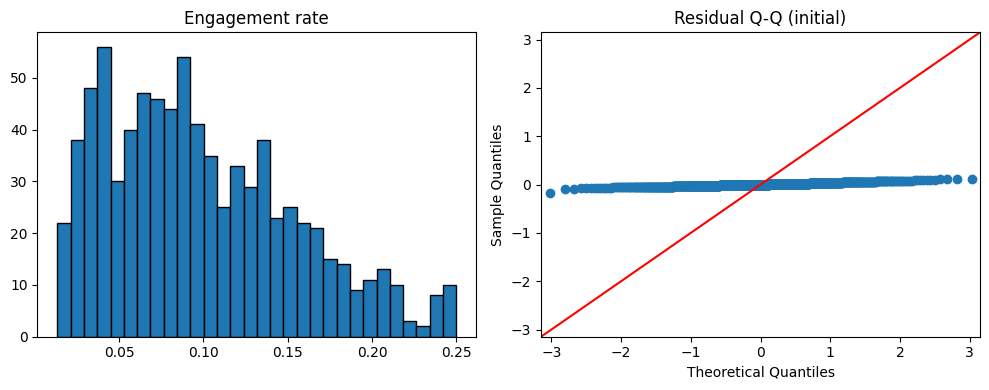

Using label: log1p(engagement_rate)
                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     21.68
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          9.63e-123
Time:                        12:40:32   Log-Likelihood:                 1676.8
No. Observations:                 812   AIC:                            -3238.
Df Residuals:                     754   BIC:                            -2965.
Df Model:                          57                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [27]:
print("Skew raw:", float(pd.Series(yA).skew()))
print("Shapiro p (subsample):", shapiro_tail(yA)[1])
print("Residual JB p:", sm.stats.stattools.jarque_bera(mA0.resid)[1])

yA_clip = np.clip(yA, 0, None)
yA_log = np.log1p(yA_clip)
yA_sqrt = np.sqrt(yA_clip)

print("Skew log1p:", float(pd.Series(yA_log).skew()))
print("Skew sqrt:", float(pd.Series(yA_sqrt).skew()))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(yA, bins=30, edgecolor="k")
ax[0].set_title("Engagement rate")
sm.qqplot(mA0.resid, line="45", ax=ax[1])
ax[1].set_title("Residual Q-Q (initial)")
plt.tight_layout()
plt.show()

# Fit transformed label if helpful
yA_used = yA
labelA_name = "engagement_rate"
if abs(pd.Series(yA_log).skew()) < abs(pd.Series(yA).skew()):
    yA_used = yA_log
    labelA_name = "log1p(engagement_rate)"

mA1, _ = ols_fit(XA, yA_used)
print("Using label:", labelA_name)
print(mA1.summary())


### Multicollinearity (VIF) and refinement
Drop features with VIF > 7 one at a time, then add the interaction `has_call_to_action × features_resident_story`.

Removed due to VIF: 3
                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     21.01
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          2.22e-117
Time:                        12:40:32   Log-Likelihood:                 1659.5
No. Observations:                 812   AIC:                            -3207.
Df Residuals:                     756   BIC:                            -2944.
Df Model:                          55                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

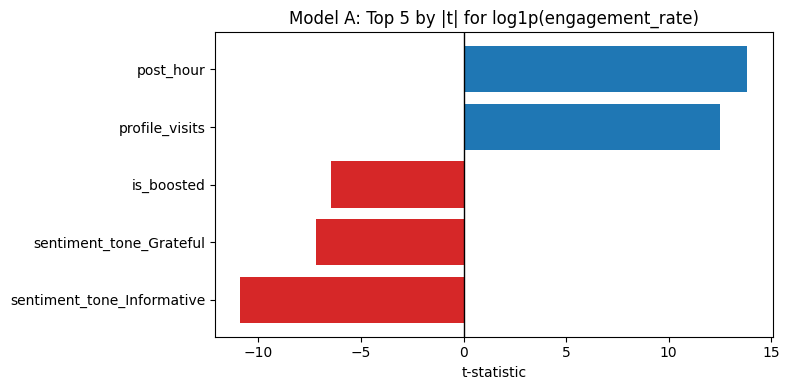

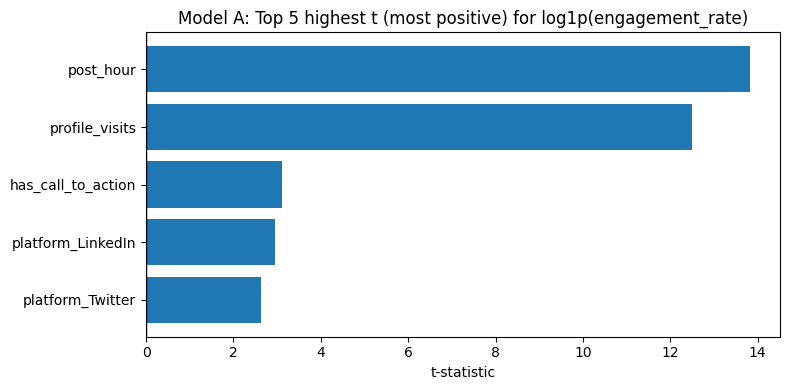

In [28]:
XA_v, removedA = remove_high_vif_one_at_a_time(XA, yA_used)
print("Removed due to VIF:", len(removedA))

XA_int = XA_v.copy()
if "has_call_to_action" in XA_int.columns and "features_resident_story" in XA_int.columns:
    XA_int["cta_x_story"] = XA_int["has_call_to_action"] * XA_int["features_resident_story"]

mA_final, _ = ols_fit(XA_int, yA_used)
print(mA_final.summary())
plot_top_t(mA_final, k=5, title=f"Model A: Top 5 by |t| for {labelA_name}")
plot_top_t_positive(mA_final, k=5, title=f"Model A: Top 5 highest t (most positive) for {labelA_name}")


## Model B: Estimated donation value (`estimated_donation_value_php`)

### Initial model
Donation value is often right-skewed; we consider log1p transformation for normality diagnostics. We also **exclude** `donation_referrals` to reduce direct leakage into the value estimate.

In [29]:
dfB = posts.dropna(subset=["estimated_donation_value_php"]).copy()
dfB["estimated_donation_value_php"] = pd.to_numeric(dfB["estimated_donation_value_php"], errors="coerce")
dfB = dfB.dropna(subset=["estimated_donation_value_php"]).copy()

dropB = [
    "post_id","platform_post_id","post_url","caption","hashtags","campaign_name",
    "created_at",
    # reduce direct leakage
    "donation_referrals",
]

XB, yB = prepare_features(dfB, "estimated_donation_value_php", extra_drop=dropB)
mB0, _ = ols_fit(XB, yB)
print(mB0.summary())


                                 OLS Regression Results                                 
Dep. Variable:     estimated_donation_value_php   R-squared:                       0.801
Model:                                      OLS   Adj. R-squared:                  0.785
Method:                           Least Squares   F-statistic:                     49.64
Date:                          Tue, 07 Apr 2026   Prob (F-statistic):          3.97e-222
Time:                                  12:40:32   Log-Likelihood:                -10019.
No. Observations:                           812   AIC:                         2.016e+04
Df Residuals:                               750   BIC:                         2.045e+04
Df Model:                                    61                                         
Covariance Type:                      nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------

### Normality checks + label transformations
We compare raw vs log1p donation values, then continue with the better-behaved label for diagnostics and refinement.

In [30]:
print("Skew raw:", float(pd.Series(yB).skew()))
print("Shapiro p (subsample):", shapiro_tail(yB)[1])
print("Residual JB p:", sm.stats.stattools.jarque_bera(mB0.resid)[1])

yB_clip = np.clip(yB, 0, None)
yB_log = np.log1p(yB_clip)
print("Skew log1p:", float(pd.Series(yB_log).skew()))

yB_used = yB
labelB_name = "estimated_donation_value_php"
if abs(pd.Series(yB_log).skew()) < abs(pd.Series(yB).skew()):
    yB_used = yB_log
    labelB_name = "log1p(estimated_donation_value_php)"

mB1, _ = ols_fit(XB, yB_used)
print("Using label:", labelB_name)
print(mB1.summary())


Skew raw: 10.836212338413674
Shapiro p (subsample): 1.0219958948845563e-47
Residual JB p: 0.0
Skew log1p: -0.38685404277715835
Using label: log1p(estimated_donation_value_php)
                                 OLS Regression Results                                 
Dep. Variable:     estimated_donation_value_php   R-squared:                       0.750
Model:                                      OLS   Adj. R-squared:                  0.730
Method:                           Least Squares   F-statistic:                     36.98
Date:                          Tue, 07 Apr 2026   Prob (F-statistic):          1.03e-185
Time:                                  12:40:32   Log-Likelihood:                -1874.0
No. Observations:                           812   AIC:                             3872.
Df Residuals:                               750   BIC:                             4163.
Df Model:                                    61                                         
Covariance Type:       

### VIF + interaction refinement
Drop VIF > 7 one at a time; add `CTA × story` interaction.

Removed due to VIF: 6
                                 OLS Regression Results                                 
Dep. Variable:     estimated_donation_value_php   R-squared:                       0.727
Model:                                      OLS   Adj. R-squared:                  0.707
Method:                           Least Squares   F-statistic:                     35.97
Date:                          Tue, 07 Apr 2026   Prob (F-statistic):          1.45e-175
Time:                                  12:40:33   Log-Likelihood:                -1910.0
No. Observations:                           812   AIC:                             3934.
Df Residuals:                               755   BIC:                             4202.
Df Model:                                    56                                         
Covariance Type:                      nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025  

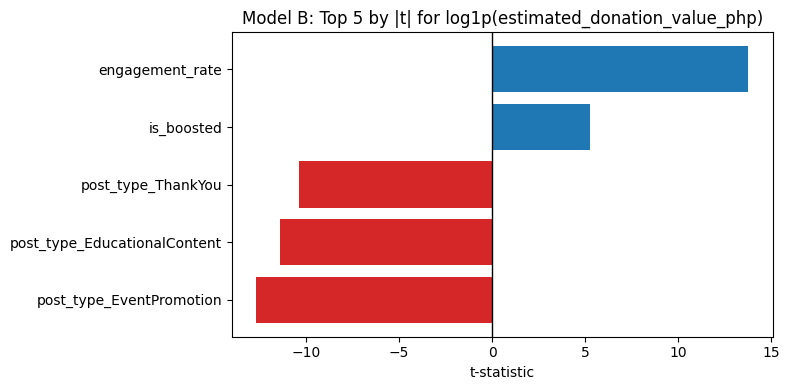

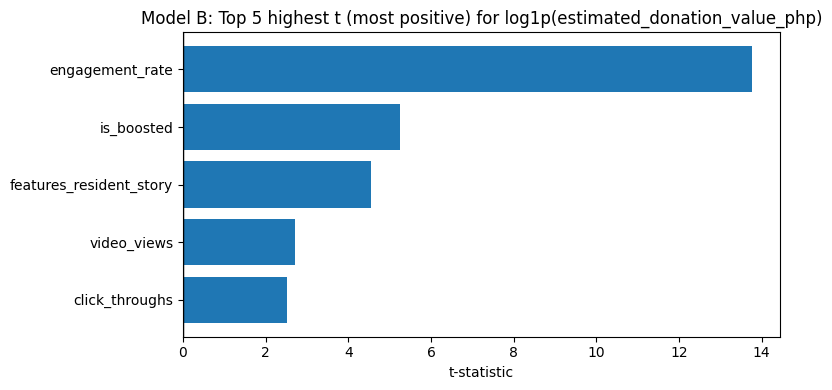

In [31]:
XB_v, removedB = remove_high_vif_one_at_a_time(XB, yB_used)
print("Removed due to VIF:", len(removedB))

XB_int = XB_v.copy()
if "has_call_to_action" in XB_int.columns and "features_resident_story" in XB_int.columns:
    XB_int["cta_x_story"] = XB_int["has_call_to_action"] * XB_int["features_resident_story"]

mB_final, _ = ols_fit(XB_int, yB_used)
print(mB_final.summary())
plot_top_t(mB_final, k=5, title=f"Model B: Top 5 by |t| for {labelB_name}")
plot_top_t_positive(mB_final, k=5, title=f"Model B: Top 5 highest t (most positive) for {labelB_name}")


## Causal / relationship analysis (short)
- Coefficients reflect **conditional associations** with engagement or donation value, not proof that a content choice *causes* the outcome.
- Platform algorithms, boosting decisions, and campaign timing are plausible confounders.

## Deployment notes
Use the strongest and most stable predictors as **hypotheses** for content strategy tests (A/B tests) and as dashboard annotations (Ch. 17).


## 3. Modeling & Feature Selection

We start with an initial OLS model, then improve interpretability/stability using label transformations (when appropriate) and multicollinearity reduction via **VIF** (dropping features with VIF > 7 one-at-a-time). We also include one interaction term tied to the business question.

## 4. Evaluation & Interpretation

### How to interpret “top t-scores” in this notebook
A feature with a large positive **t-statistic** is strongly and positively associated with the target *after controlling for the other included variables*.

Because this is **explanatory**, we evaluate the model primarily by:
- **Reasonableness** (does it match how social content works?),
- **Diagnostics** (residual checks, transformations),
- **Leakage checks** (avoid using components that literally define the target).

### Model A (target: `engagement_rate`) — key findings
In the refined `engagement_rate` model, the strongest positive t-scores were:
- **`post_hour`**
- **`profile_visits`**
- **`has_call_to_action`**
- **`platform_LinkedIn`** (relative to the baseline platform)
- **`platform_Twitter`** (relative to the baseline platform)

**Business interpretation:**
- **Timing matters (`post_hour`).** Posts at certain hours are associated with higher engagement rate. This is actionable: schedule experiments around the best-performing hours.
- **Intent signals (`profile_visits`).** Posts that drive profile visits tend to have higher engagement. This likely captures “users cared enough to learn more,” which aligns with engagement.
- **CTA helps (`has_call_to_action`).** Calls-to-action are associated with higher engagement rate, consistent with marketing theory: explicit prompts increase interactions.
- **Platform effects.** Differences by platform dummy variables suggest that the same content strategy may perform differently depending on where it is posted.

### Model B (target: `estimated_donation_value_php`) — key findings
In the refined donation-value model, the strongest positive t-scores were:
- **`engagement_rate`**
- **`is_boosted`**
- **`features_resident_story`**
- **`video_views`**
- **`click_throughs`**

**Business interpretation:**
- **Engagement is a leading indicator of donation value.** Posts that get more engagement are associated with higher estimated donation value. Practically: engagement can be used as an early “content quality” signal.
- **Boosting is associated with higher donation value (`is_boosted`).** This may reflect true uplift *or* selection bias (teams boost posts they expect to do well).
- **Resident stories correlate with higher value (`features_resident_story`).** This supports the idea that narrative content can deepen donor motivation.
- **Video and clicks matter.** `video_views` and `click_throughs` suggest that deeper attention and action correlate with donation value.

### Important caution
Some of these variables (especially `engagement_rate`) can be **mediators** rather than root causes. For example: stories → engagement → donation value. That’s still useful for strategy, but you should avoid claiming direct causation without stronger evidence.

## 5. Causal and Relationship Analysis

### A defensible relationship story (what the data suggests)
Across both models, a consistent pattern emerges:
- **Content + distribution choices** (timing, CTA, platform, boosting) are associated with **engagement**, and
- **Engagement + story-based content** are associated with higher **estimated donation value**.

### What we can (and cannot) claim
- **We can claim:** “These features are associated with higher engagement / higher estimated donation value, controlling for other available fields.”
- **We cannot claim:** “CTA causes higher donations” or “boosting causes higher donations,” because of strong confounding.

### Confounders and limitations (why correlation ≠ causation)
- **Algorithmic confounding:** platforms decide what gets shown; visibility changes engagement.
- **Selection bias in boosting:** staff choose which posts to boost.
- **Campaign context:** fundraising campaigns may drive both engagement and donation estimates.
- **Post performance feedback loop:** posts that begin to perform well may get additional distribution and attention.

### What would make causal claims stronger
- Run **A/B tests** on CTAs (same story, randomized CTA vs no-CTA).
- Randomize **post timing** within a controlled window.
- Use a consistent boosting rule (or randomized boosting budget allocation) to isolate boosting effects.

### Business insights to take forward
- **Use CTA + story as a hypothesis, not a conclusion.** The association is strong enough to justify structured experimentation.
- **Use engagement metrics as early screening.** High engagement posts are good candidates for conversion-focused follow-ups (links, donation prompts, retargeting).

## 6. Deployment Notes

These notebooks are designed to be run end-to-end by a TA. For the deployed web app, the *intended* integration is to surface the key model outputs (top relationships, coefficient directions, and diagnostics) in dashboards or admin views.

If your app currently has an `artifacts/` or model-output folder, you can export summary tables/figures there from this notebook (e.g., coefficient tables as CSV). If integration code isn’t yet in the repo, keep this section honest and describe the planned endpoint/component that will display results.